In [1]:
import os
from upsetplot import from_contents, plot
from denovo_utils.data import Run
from denovo_utils.parsers import DenovoEngineConverter
from denovo_utils.io.read import load_pickle

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from denovo_utils.analysis.metrics import load_seq_score_dicts
from denovo_utils.analysis.metrics import get_match_score_table, get_prc_curve

from psm_utils import Peptidoform
from tqdm import tqdm
from peak_pack.utils import calculate_ppm

import numpy as np
from itertools import permutations, combinations

2026-09-09 15:39:28.529577: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


# Upsetplot and overlap matrix

In [2]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

In [3]:
runs = load_pickle('runs_PXD028735_QExactive.pkl')

In [4]:
class Selector:
    @staticmethod
    def get_spectra_from_model(run, denovo_models, include_gold_standard=False):
        spectra = {}
        for spectrum_id, spectrum in run.spectra.items():
            psms = []
            common = True
            for denovo_name in denovo_models:
                psm = spectrum.get_psms_by_engine(engine_name=denovo_name)
                if len(psm) == 0:
                    common = False
                    break
                psms += psm
            if common:
                if include_gold_standard:
                    psms += spectrum.psm_gold_standard
                spectra[spectrum_id] = spectrum
        
        new_run = Run(run.run_id)
        new_run.spectra = spectra
        return new_run

denovo_engines = denovo_names = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'InstaNovo',
    'NovoB',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]
denovo_engines_selection = [
    'Casanovo4.2.0',
    'NovoB',
    'InstaNovo',
    'pi-PrimeNovo',
    'AdaNovo',
    'pi-HelixNovo'
]

## 1. Create identification overlap sets

In [5]:
correct_by_engine = {engine: [] for engine in denovo_engines}
# Iterate over the runs
for run_name, run in runs.items():
    # Iterate over the models
    for engine in denovo_engines:
        # Select the psms for which the current de novo model has predictions
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        # Iterate over the spectra
        for specid, spectrum in run_engine.spectra.items():
            # Get the identification of the model
            psm = spectrum.get_psms_by_engine(engine)[0]
            # Check whether the psm matches wiht one of the gold standards
            if psm.metadata['match_type']=='match':
                # If so, append as run_spectrum_peptidoform
                correct_by_engine[engine].append(
                    f'{run_name}_{specid}_{psm.peptidoform.proforma}'
                )

correct_by_engine_spectra = {engine: [] for engine in denovo_engines}
for run_name, run in runs.items():
    for engine in denovo_engines:
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        for specid, spectrum in run_engine.spectra.items():
            psm = spectrum.get_psms_by_engine(engine)[0]
            if psm.metadata['match_type']=='match':
                correct_by_engine_spectra[engine].append(
                    f'{run_name}_{specid}'
                )

false_by_engine = {engine: [] for engine in denovo_engines}
for run_name, run in runs.items():
    for engine in denovo_engines:
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        for specid, spectrum in run_engine.spectra.items():
            psm = spectrum.get_psms_by_engine(engine)[0]
            if psm.metadata['match_type']!='match':
                false_by_engine[engine].append(
                    f'{run_name}_{specid}_{psm.peptidoform.proforma}'
                )

all_by_engine = {engine: [] for engine in denovo_engines}
for run_name, run in runs.items():
    for engine in denovo_engines:
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        for specid, spectrum in run_engine.spectra.items():
            psm = spectrum.get_psms_by_engine(engine)[0]
            all_by_engine[engine].append(
                f'{run_name}_{specid}_{psm.peptidoform.proforma}'
            )

In [6]:
# Upset
upset_data_correct = from_contents(correct_by_engine)
# Reindex
upset_data_correct_reindexed = upset_data_correct.reset_index()
# Count the number of denovo models that had a correct identification
upset_data_correct_reindexed['n_correct'] = upset_data_correct_reindexed[denovo_engines].sum(axis=1)
# Add the spectrum id as run_spectrumid
upset_data_correct_reindexed['spectrum_id'] = upset_data_correct_reindexed['id'].apply(
    lambda x: '_'.join(x.split('_')[:-1])
)

upset_data_correct_spectrum = from_contents(correct_by_engine_spectra)
upset_data_correct_spectrum_reindexed = upset_data_correct_spectrum.reset_index()
upset_data_correct_spectrum_reindexed['n_correct'] = upset_data_correct_spectrum_reindexed[denovo_engines].sum(axis=1)
upset_data_correct_spectrum_reindexed['spectrum_id'] = upset_data_correct_spectrum_reindexed['id']

upset_data_false = from_contents(false_by_engine)
upset_data_false_reindexed = upset_data_false.reset_index()
upset_data_false_reindexed['n_false'] = upset_data_false_reindexed[denovo_engines].sum(axis=1)
upset_data_false_reindexed['spectrum_id'] = upset_data_false_reindexed['id'].apply(
    lambda x: '_'.join(x.split('_')[:-1])
)

n_spectra = len(pd.Series(
    upset_data_false_reindexed['spectrum_id'].tolist() + 
    upset_data_correct_spectrum_reindexed['spectrum_id'].tolist()
).drop_duplicates())
n_spectra_correct = upset_data_correct_reindexed['spectrum_id'].nunique()

## Percentages correctness overlap

In [7]:
n_spectra_correct/n_spectra

0.6421270247842709

% Of all spectra

In [10]:
# Percentage of all spectra which were identified correctly by n spectra.
(upset_data_correct_spectrum_reindexed['n_correct'].value_counts() / n_spectra *100).sort_index()

n_correct
1     9.471937
2     7.113426
3     6.219331
4     5.892680
5     6.270656
6     8.384538
7    12.770591
8     8.089544
Name: count, dtype: float64

In [11]:
# Percentage of all spectra which were identified correctly by n spectra (Cumulatively)
(upset_data_correct_spectrum_reindexed['n_correct'].value_counts() / n_spectra *100).sort_index(ascending=False).cumsum()

n_correct
8     8.089544
7    20.860135
6    29.244672
5    35.515328
4    41.408008
3    47.627339
2    54.740765
1    64.212702
Name: count, dtype: float64

% Of correct spectra

In [12]:
# Same as above but with percentage relative to the set of spectra acquiring at least a single correct prediction
(upset_data_correct_spectrum_reindexed['n_correct'].value_counts() / n_spectra_correct *100).sort_index()

n_correct
1    14.750878
2    11.077911
3     9.685516
4     9.176813
5     9.765444
6    13.057444
7    19.887951
8    12.598043
Name: count, dtype: float64

In [13]:
(upset_data_correct_spectrum_reindexed['n_correct'].value_counts() / n_spectra_correct *100).sort_index(ascending=False).cumsum()

n_correct
8     12.598043
7     32.485994
6     45.543438
5     55.308882
4     64.485695
3     74.171211
2     85.249122
1    100.000000
Name: count, dtype: float64

In [14]:
upset_data_correct_spectrum_reindexed[
    upset_data_correct_spectrum_reindexed[
        denovo_engines_selection
    ].sum(axis=1)>=6
]['id'].nunique() / n_spectra_correct

0.34356465227459476

Unique correct

In [15]:
print('Percentage of all correct spectra')
for engine in denovo_engines:
    n = len(upset_data_correct_spectrum_reindexed[
        (upset_data_correct_spectrum_reindexed['n_correct']==1) &
        (upset_data_correct_spectrum_reindexed[engine])
    ]) / n_spectra_correct
    print('{}: \t{:.3f}'.format(engine, n*100))

print()
print('Percentage of total spectra')
for engine in denovo_engines:
    n = len(upset_data_correct_spectrum_reindexed[
        (upset_data_correct_spectrum_reindexed['n_correct']==1) &
        (upset_data_correct_spectrum_reindexed[engine])
    ]) / n_spectra
    print('{}: \t{:.3f}'.format(engine, n*100))

Percentage of all correct spectra
AdaNovo: 	0.880
Casanovo4.2.0: 	0.973
ContraNovo: 	1.575
InstaNovo: 	2.528
NovoB: 	3.757
PepNet: 	0.252
pi-HelixNovo: 	0.722
pi-PrimeNovo: 	4.065

Percentage of total spectra
AdaNovo: 	0.565
Casanovo4.2.0: 	0.625
ContraNovo: 	1.012
InstaNovo: 	1.623
NovoB: 	2.412
PepNet: 	0.162
pi-HelixNovo: 	0.463
pi-PrimeNovo: 	2.610


In [21]:
from upsetplot import UpSet

def upset_source_data(data, figure=None, sort_by="cardinality", min_subset_size=None, **kw):
    """Tidy source-data tables for an UpSet plot.

    Returns (intersections, set_totals). `intersections` lists every non-empty
    intersection with a `plotted` flag, so a reader can see what min_subset_size
    left out of the figure.
    """
    n_total = len(data)
    full  = UpSet(data, sort_by=sort_by, **kw).intersections.rename("size")
    shown = set(UpSet(data, sort_by=sort_by, min_subset_size=min_subset_size,
                      **kw).intersections.index) if min_subset_size else set(full.index)

    inter = full.reset_index()
    setcols = [c for c in inter.columns if c != "size"]
    inter.insert(0, "models", inter[setcols].apply(
        lambda r: " & ".join(c for c in setcols if r[c]) or "(none)", axis=1))
    inter.insert(1, "n_models", inter[setcols].sum(axis=1))
    inter["percent_of_total"] = (100 * inter["size"] / n_total).round(3)
    inter["plotted"] = [tuple(t) in shown for t in full.index]
    inter = inter[["models", "n_models", "size", "percent_of_total", "plotted"] + setcols]

    tot = UpSet(data, sort_by=sort_by, **kw).totals.rename("total").rename_axis("model").reset_index()
    tot["percent_of_total"] = (100 * tot["total"] / n_total).round(3)

    if figure:
        inter.insert(0, "figure", figure); tot.insert(0, "figure", figure)
    return inter, tot


inter, tot = upset_source_data(upset_data_correct_spectrum,
                               figure="Figure 1DE", min_subset_size=1000)

with pd.ExcelWriter("source_data/Source_Data_Figure1.xlsx", engine="openpyxl", mode='a', if_sheet_exists='replace') as xl:
    inter.to_excel(xl, sheet_name="DE_intersections", index=False)
    tot.to_excel(xl, sheet_name="DE_totals", index=False)

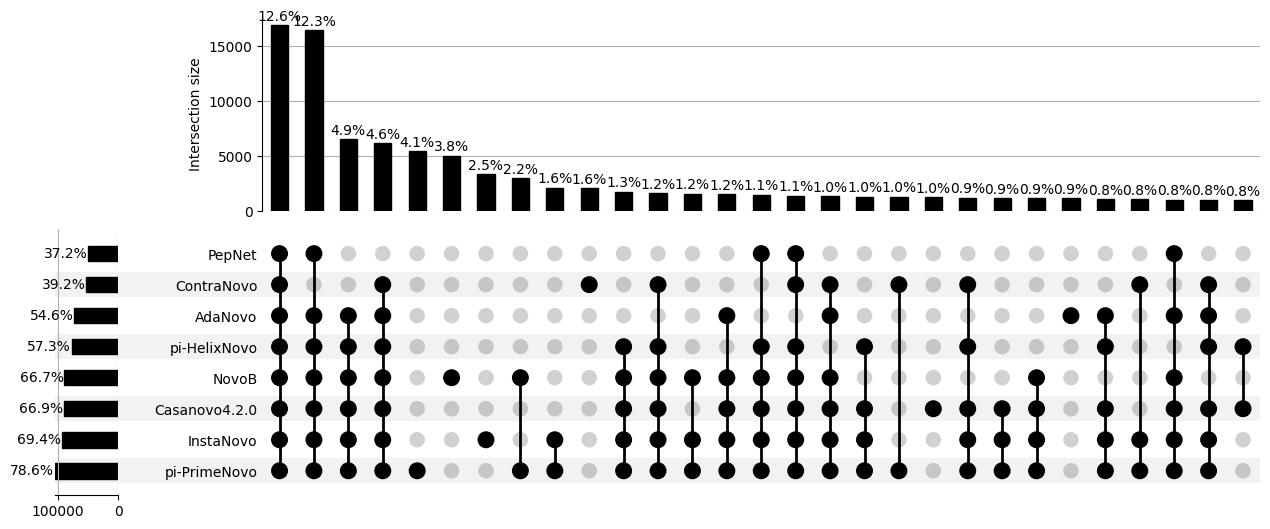

In [18]:
p = plot(upset_data_correct_spectrum, sort_by='cardinality', show_percentages=True, min_subset_size=1000)
plt.show('F1D_UpsetCorrect')

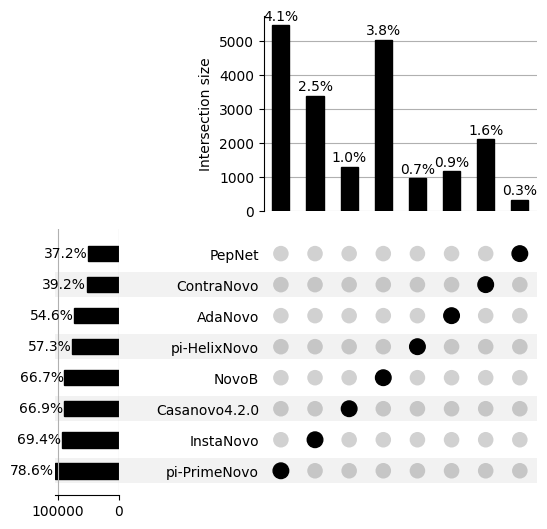

In [19]:
p = plot(
    upset_data_correct_spectrum,
    min_degree=1, max_degree=1, show_percentages=True
)
plt.show('F1E_UpsetCorrectUnique')

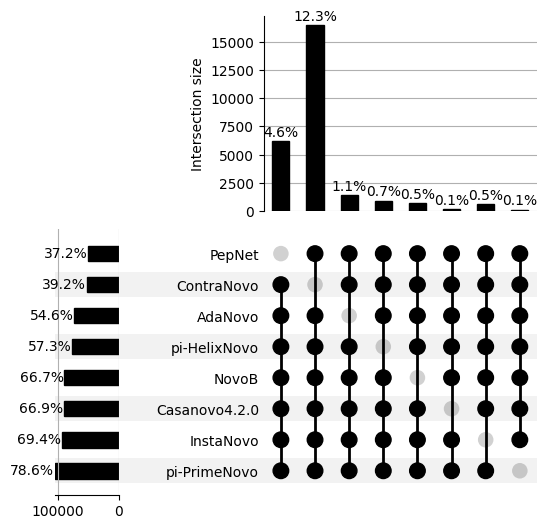

In [20]:
p = plot(
    upset_data_correct_spectrum,
    min_degree=7, max_degree=7, show_percentages=True
)
plt.show('Other_UpsetCorrectAllButOne')

# Agreement for false identifications

In [53]:
upset_data_false_reindexed[upset_data_false_reindexed['n_false']>=8]['id'].nunique() / n_spectra

0.0017411825651504468

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

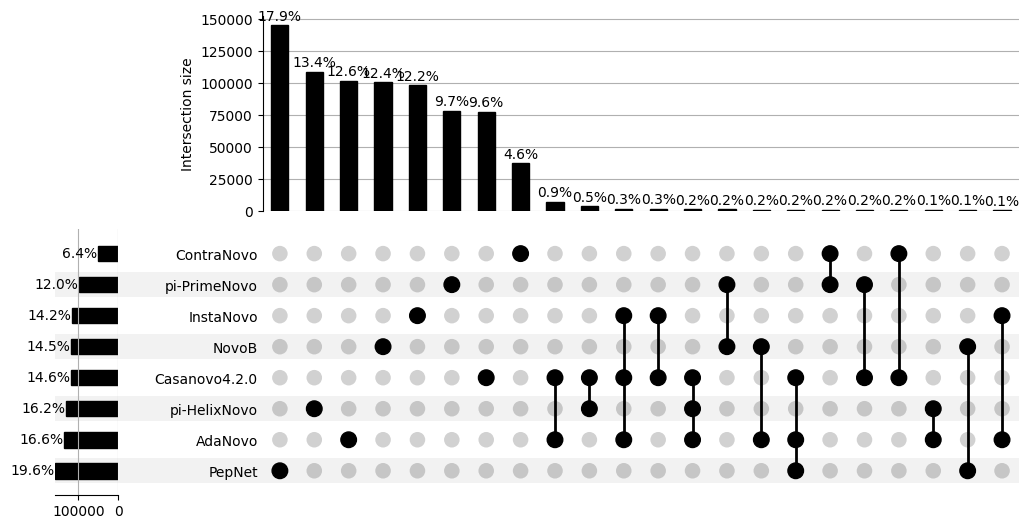

In [61]:
plot(upset_data_false, sort_by='cardinality', show_percentages=True, min_subset_size=1000)

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

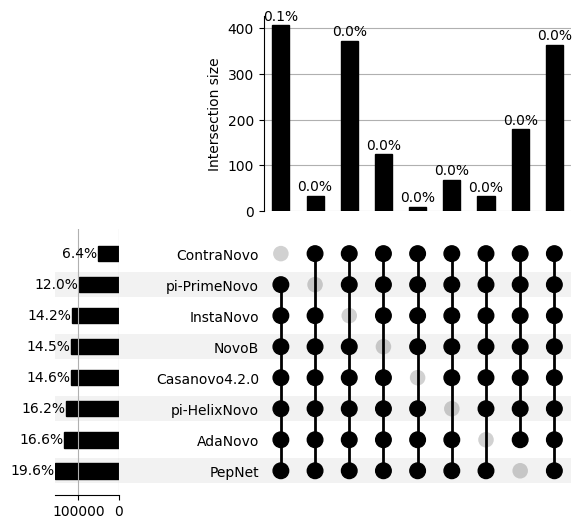

In [62]:
plot(
    upset_data_false,
    min_degree=7, max_degree=8, show_percentages=True
)

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

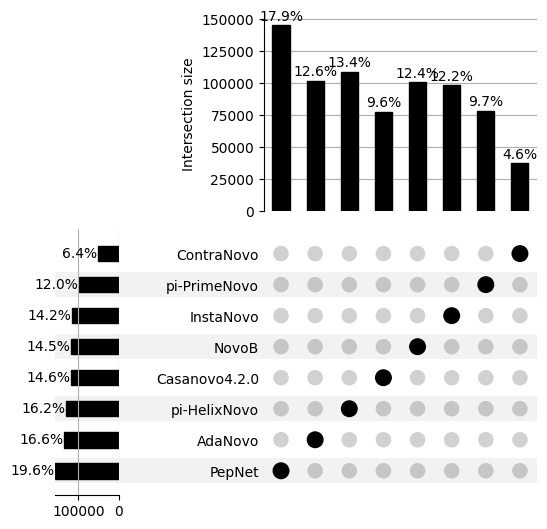

In [63]:
plot(
    upset_data_false,
    min_degree=1, max_degree=1, show_percentages=True
)

# Pairwise heatmaps

In [8]:
def get_overlap(list1, list2):
    set_1, set_2 = set(list1), set(list2)
    intersection = set_1.intersection(set_2)

    if len(set_1) == 0:
        overlap_tool_1 = 0
    else:
        overlap_tool_1 = len(intersection) / len(set_1)
    if len(set_2) == 0:
        overlap_tool_2 = 0
    else:
        overlap_tool_2 = len(intersection) / len(set_2)

    return overlap_tool_1, overlap_tool_2

def get_overlap_matrix(dict_of_lists, denovo_engines):
    overlap_matrix = np.ones((len(denovo_engines), len(denovo_engines)))

    for (engine_1, engine_2) in combinations(denovo_engines, 2):
        i = denovo_engines.index(engine_1)
        j = denovo_engines.index(engine_2)
        overlap_1, overlap_2 = get_overlap(
            dict_of_lists[engine_1],
            dict_of_lists[engine_2]
        )
        overlap_matrix[i, j] = overlap_1
        overlap_matrix[j, i] = overlap_2
    return overlap_matrix

In [9]:
all_overlap_matrix = get_overlap_matrix(all_by_engine, denovo_engines=denovo_engines)
correct_overlap_matrix = get_overlap_matrix(correct_by_engine, denovo_engines=denovo_engines)
correct_overlap_matrix_spectrum = get_overlap_matrix(correct_by_engine_spectra, denovo_engines=denovo_engines)
false_overlap_matrix = get_overlap_matrix(false_by_engine, denovo_engines=denovo_engines)

<Axes: >

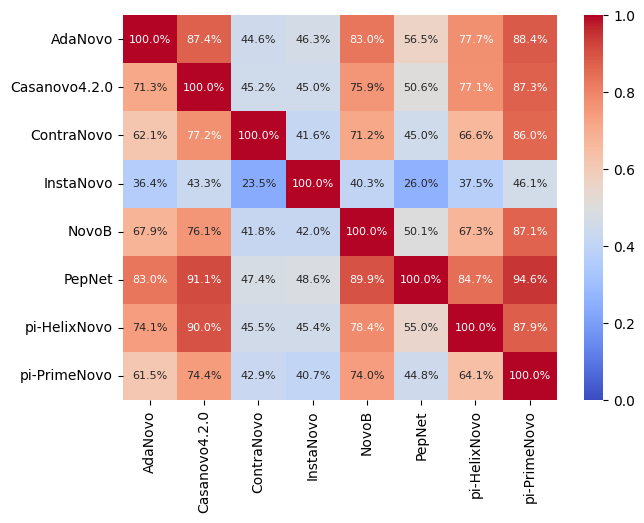

In [67]:
plt.figure(figsize=(7,5))
sns.heatmap(
    correct_overlap_matrix,
    annot=True,
    cmap="coolwarm",
    xticklabels=denovo_engines,
    yticklabels=denovo_engines,
    vmin=0,
    vmax=1,
    fmt=".1%",
    annot_kws={"size": 8}
)

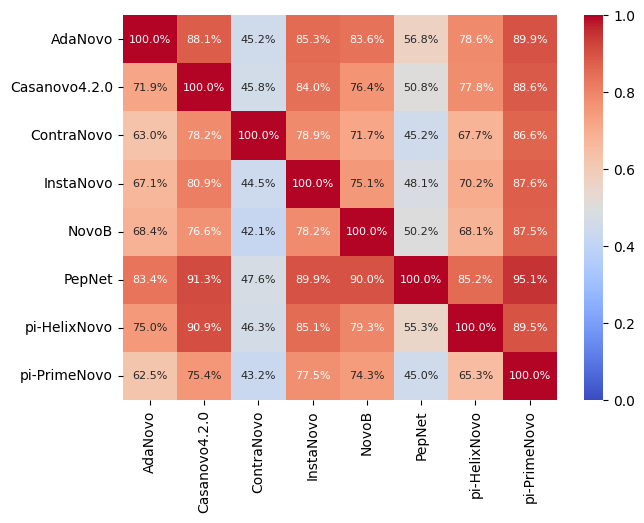

In [23]:
plt.figure(figsize=(7,5))
sns.heatmap(
    correct_overlap_matrix_spectrum,
    annot=True,
    cmap="coolwarm",
    xticklabels=denovo_engines,
    yticklabels=denovo_engines,
    vmin=0,
    vmax=1,
    fmt=".1%",
    annot_kws={"size": 8}
)
plt.show('Suppl_OverlapMatrixCorrect')

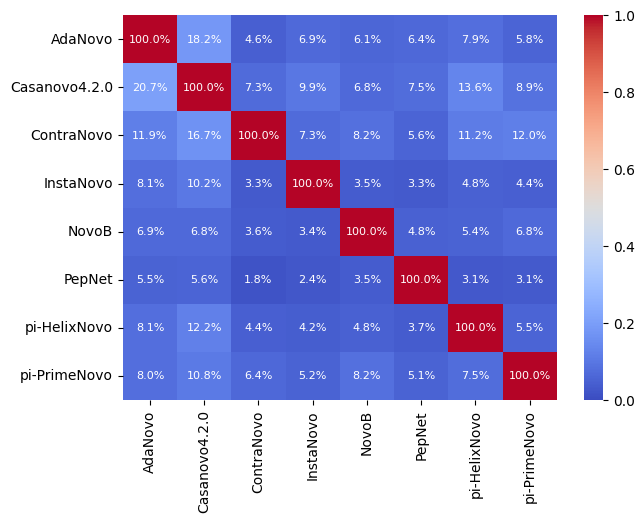

In [24]:
plt.figure(figsize=(7,5))
sns.heatmap(
    false_overlap_matrix,
    annot=True,
    cmap="coolwarm",
    xticklabels=denovo_engines,
    yticklabels=denovo_engines,
    vmin=0,
    vmax=1,
    fmt=".1%",
    annot_kws={"size": 8}
)
plt.show('Suppl_OverlapMatrixIncorrect')

In [16]:
with pd.ExcelWriter('source_data/Source_Data_Suppl_Fig3.xlsx', engine="openpyxl") as xl:
    pd.DataFrame(correct_overlap_matrix_spectrum, columns=denovo_engines, index=denovo_engines).to_excel(xl, sheet_name="A")
    pd.DataFrame(false_overlap_matrix, columns=denovo_engines, index=denovo_engines).to_excel(xl, sheet_name="B")

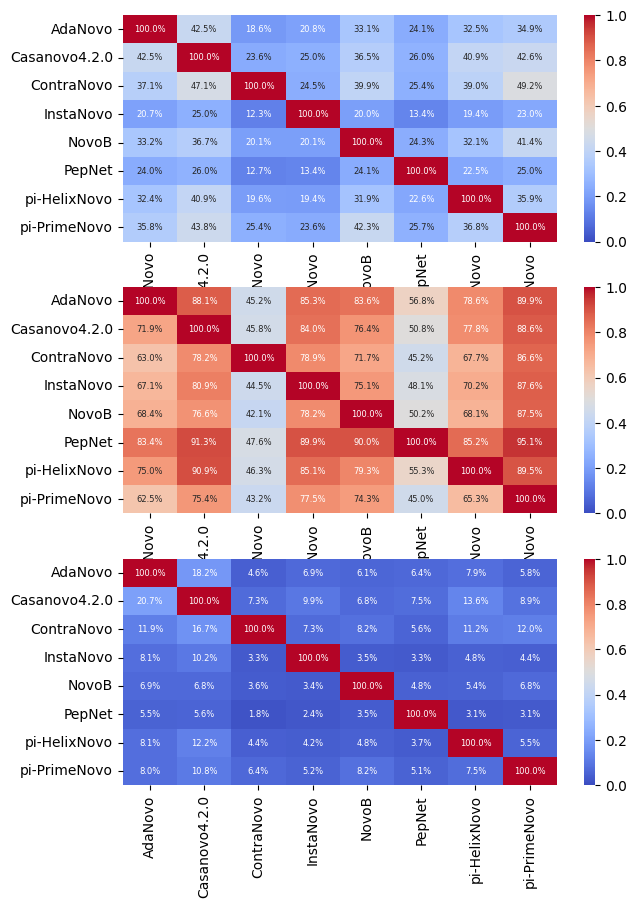

In [71]:
fig, ax = plt.subplots(3,1, figsize=(7,10))
for i, om in enumerate([all_overlap_matrix, correct_overlap_matrix_spectrum, false_overlap_matrix]):
    sns.heatmap(
        om,
        annot=True,
        cmap="coolwarm",
        xticklabels=denovo_engines,
        yticklabels=denovo_engines,
        ax=ax[i],
        vmin=0,
        vmax=1,
        fmt=".1%",
        annot_kws={"size": 6}
    )

# Overlapping predictions but in FASTA

In [25]:
upset_data_false

id
AdaNovo Casanovo4.2.0 ContraNovo InstaNovo NovoB PepNet pi-HelixNovo pi-PrimeNovo                                                   
True    False         False      False     False False  False        False         LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...
                                           True  False  False        True          LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...
        True          True       False     False False  True         False         LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...
        False         False      False     False False  False        False         LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...
                                                                     False         LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...
...                                                                                                                              ...
False   False         False      False     False False  False        True          LFQ_Orbitrap_DDA_Yeast_01_controllerType=0 con...
                                                                     True          LFQ_Orbitrap_DDA_Yeast_01_controllerType=0 con...
                                                                     True          LFQ_Orbitrap_DDA_Yeast_01_controllerType=0 con...
                                                                     True          LFQ_Orbitrap_DDA_Yeast_01_controllerType=0 con...
                                                                     True          LFQ_Orbitrap_DDA_Yeast_01_controllerType=0 con...

[809942 rows x 1 columns]

In [27]:
common_in_fasta = {}

for num_common in range(5,9):

    # Get spectra which have the same prediction for num_common de novo models but are still wrongly predicted
    common_false_ids = upset_data_false[(upset_data_false.reset_index()[denovo_engines].sum(axis=1) >= num_common).to_numpy()]['id'].tolist()

    # Get the spectrum_ids for these spectra
    common_false_specids = [('_'.join(i.split('_')[:-2]), i.split('_')[-2]) for i in common_false_ids]

    match_types_all_false = {}
    for (run_name, specid) in common_false_specids:
        # Extract these spectra from the run object
        spectrum = runs[run_name].get_spectrum(specid)
        error_types = {}
        for psm in spectrum.psm_candidates:
            # Store the match types for these psms
            try:
                error_types[psm.metadata['match_type']] += 1
            except:
                error_types[psm.metadata['match_type']] = 1
        
        # Just take the max (only works when num_common > num_denovo_models/2)
        error_type = max(error_types, key=error_types.get)
        
        match_types_all_false['|'.join([run_name, specid])] = [error_type]

    # Count them
    common_in_fasta[num_common] = pd.DataFrame(match_types_all_false).T.value_counts(normalize=True)


In [28]:
pd.DataFrame(common_in_fasta).T

,No match - In FASTA,No match - Not in FASTA
5,0.600776,0.399224
6,0.668305,0.331695
7,0.720579,0.279421
8,0.730028,0.269972


# Plot a couple of spectra

Annotated by all models, but still wrongly predicted

In [23]:
specids_all_false = pd.DataFrame(upset_data_false_reindexed[upset_data_false_reindexed['n_false']>=8]['id'].unique()).rename(
    columns={0: 'code'}
)
specids_all_false['run'] = specids_all_false.apply(lambda x: x['code'].split('_controller')[0], axis=1)
specids_all_false['specid'] = specids_all_false.apply(lambda x: 'controller' + '_'.join(x['code'].split('_controller')[1].split('_')[:-1]), axis=1)
specids_all_false.head(10)

,code,run,specid
0,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=44300
1,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=57947
2,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=68814
3,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=50248
4,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=63068
5,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=22477
6,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=69809
7,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=73439
8,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=72042
9,LFQ_Orbitrap_DDA_Ecoli_01_controllerType=0 con...,LFQ_Orbitrap_DDA_Ecoli_01,controllerType=0 controllerNumber=1 scan=28877


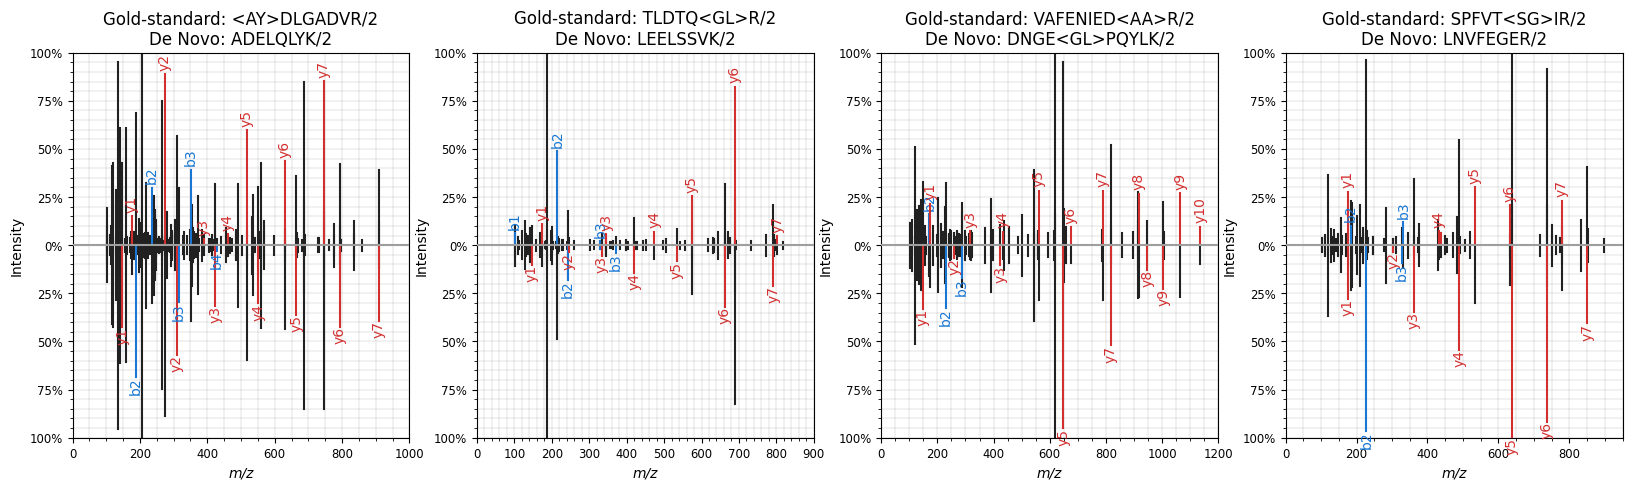

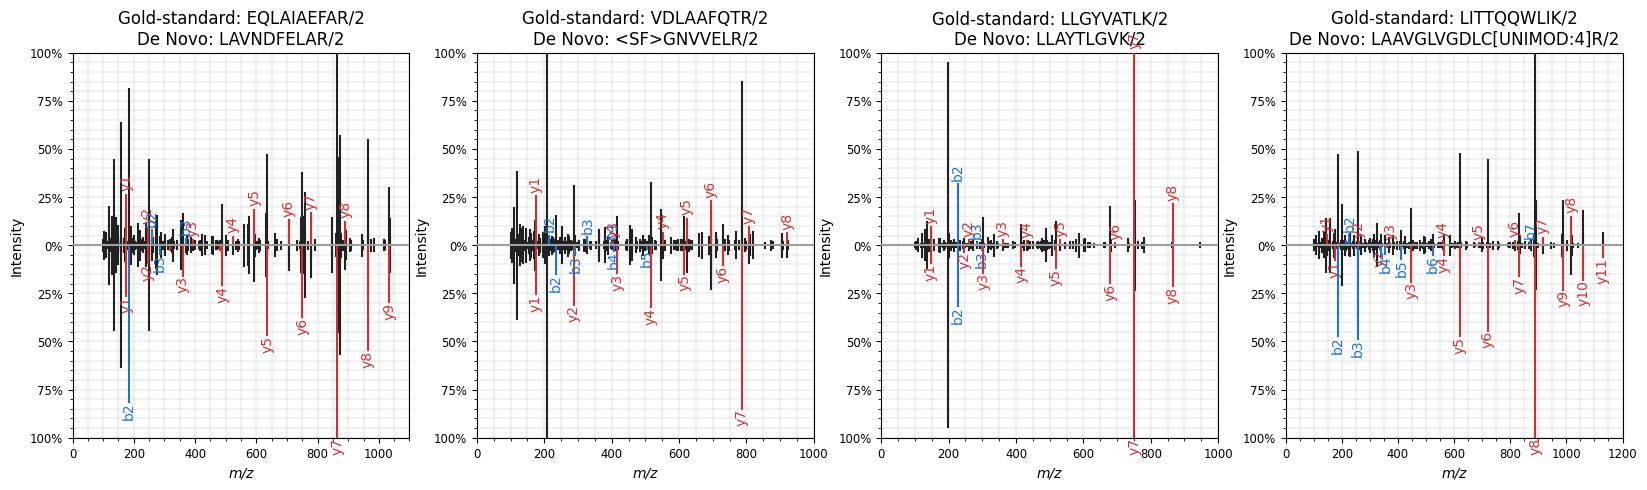

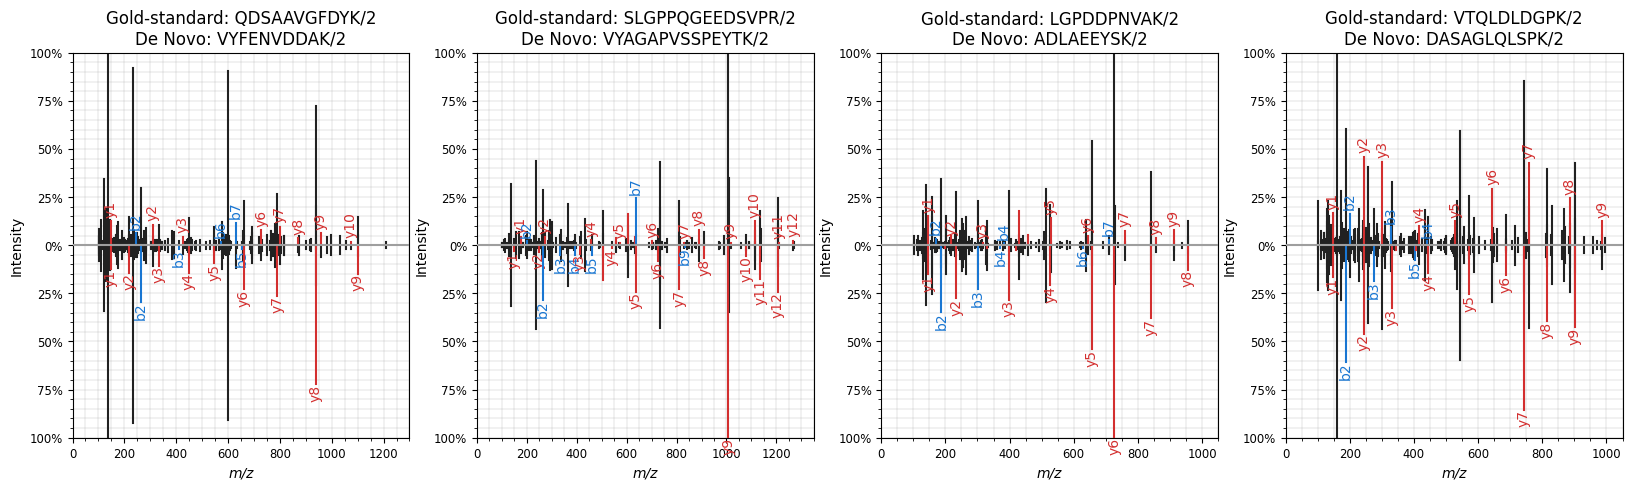

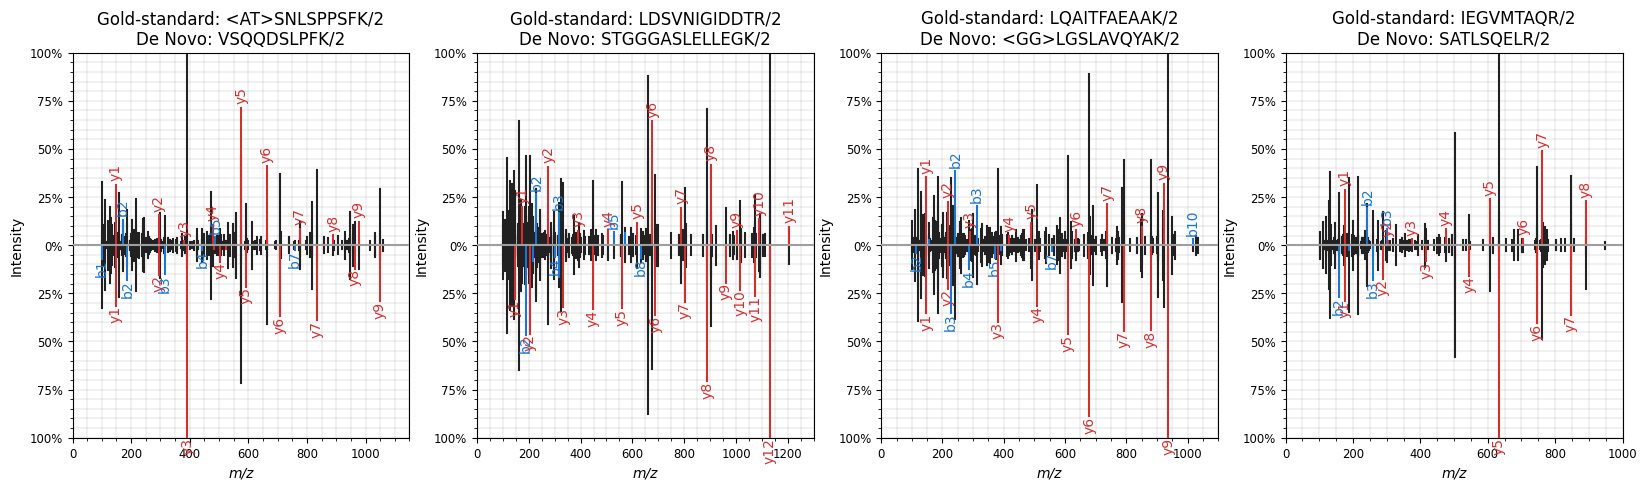

In [24]:
import spectrum_utils.plot as sup
from denovo_utils.analysis.visualization import plot_spectrum


def create_mirror(root, run_name, specid, pep_1, pep_2):

    plot_1 = plot_spectrum(
        peak_path=os.path.join(root, run_name),
        spectrum_id=specid,
        peptide=pep_1,
        peak_format='mgf',
        plot=False
    )
    plot_2 = plot_spectrum(
        peak_path=os.path.join(root, run_name),
        spectrum_id=specid,
        peptide=pep_2,
        peak_format='mgf',
        plot=False
    )
    return plot_1, plot_2


for run_name, run in runs.items():
    fig, ax = plt.subplots(1,4, figsize=(20,5))
    i = 0
    for specid in specids_all_false[specids_all_false['run']==run_name]['specid'].tolist():
        spectrum = run.get_spectrum(specid)
        
        if spectrum.psm_candidates[0].metadata['match_type'] != 'No match - In FASTA':
            continue

        p1, p2 = create_mirror(
            root='/public/compomics3/Sam/PXD028735/QExactive/mgf_reformatted',
            run_name=f'{run_name}.mgf',
            specid=specid,
            pep_1=spectrum.psm_gold_standard[0].peptidoform.proforma,
            pep_2=spectrum.psm_candidates[0].peptidoform.proforma
        )
        sup.mirror(p1,p2, ax=ax[i])
        ax[i].set_title(f'Gold-standard: {spectrum.psm_gold_standard[0].peptide_evidence}\nDe Novo: {spectrum.psm_candidates[0].peptide_evidence}')
        i += 1
        if i == 4:
            break
    fig.show()
    plt.show(f"Suppl_mirrorspec_{run_name}_panel_2")

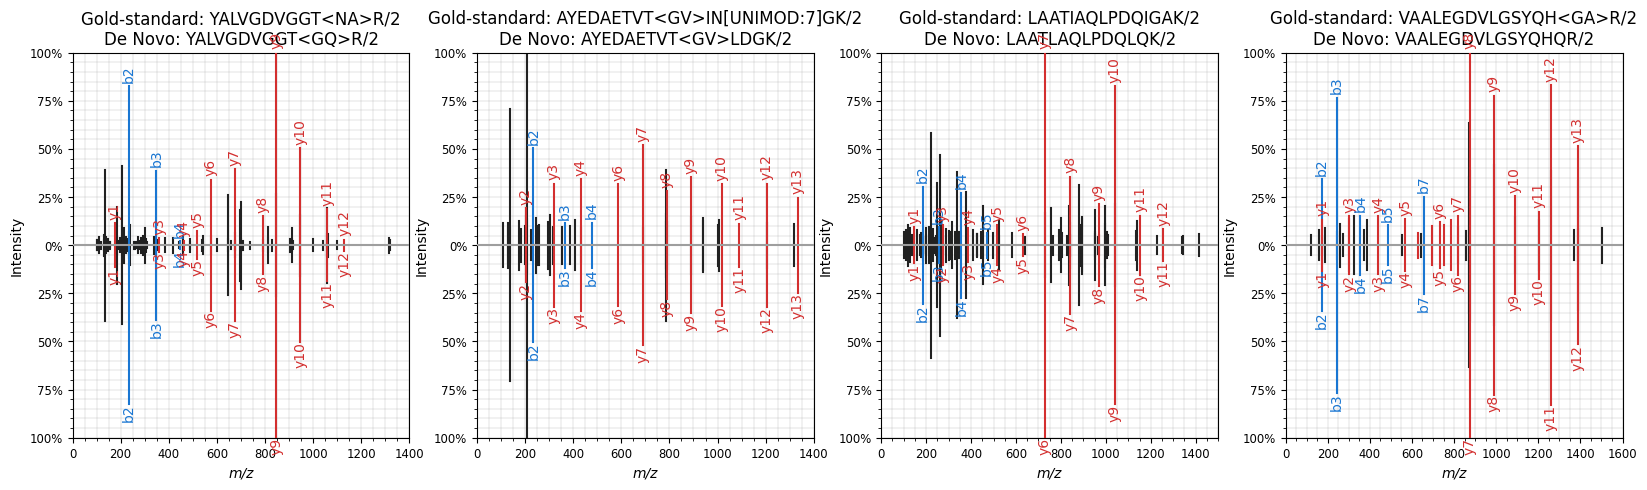

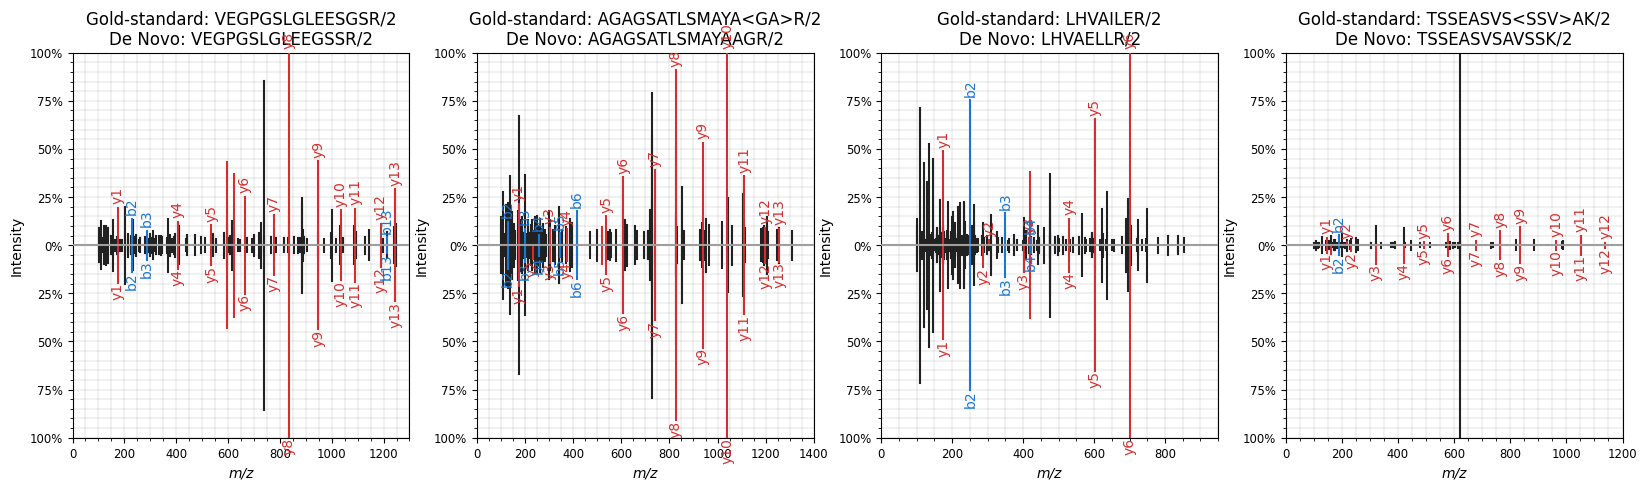

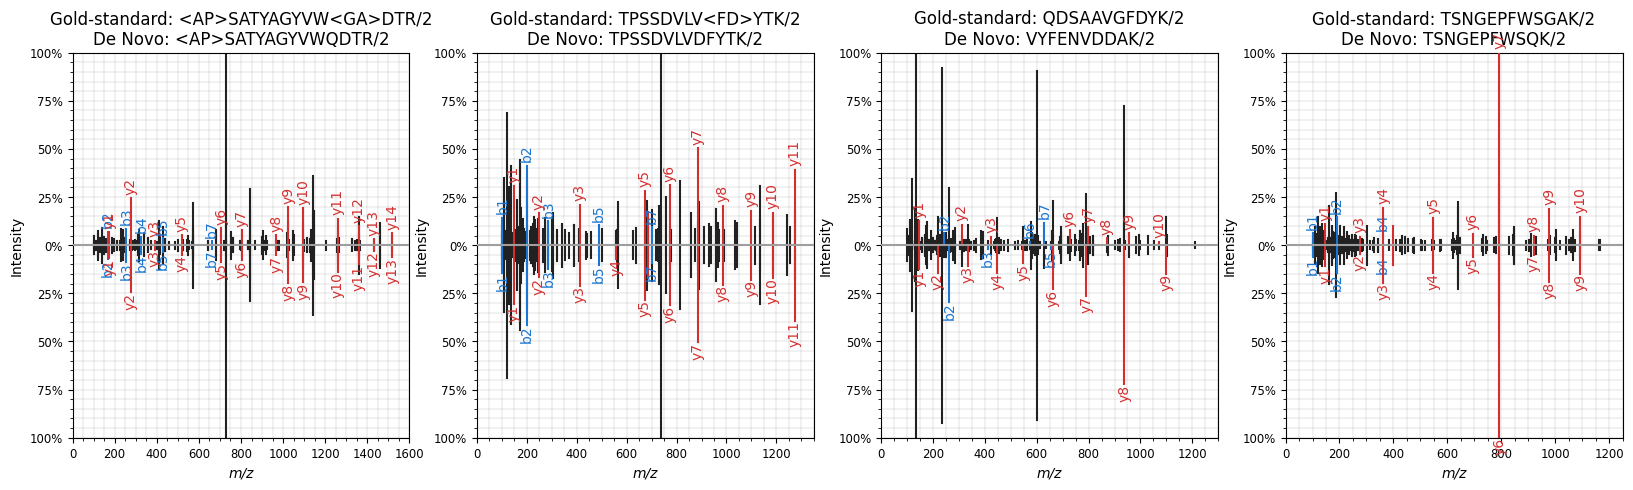

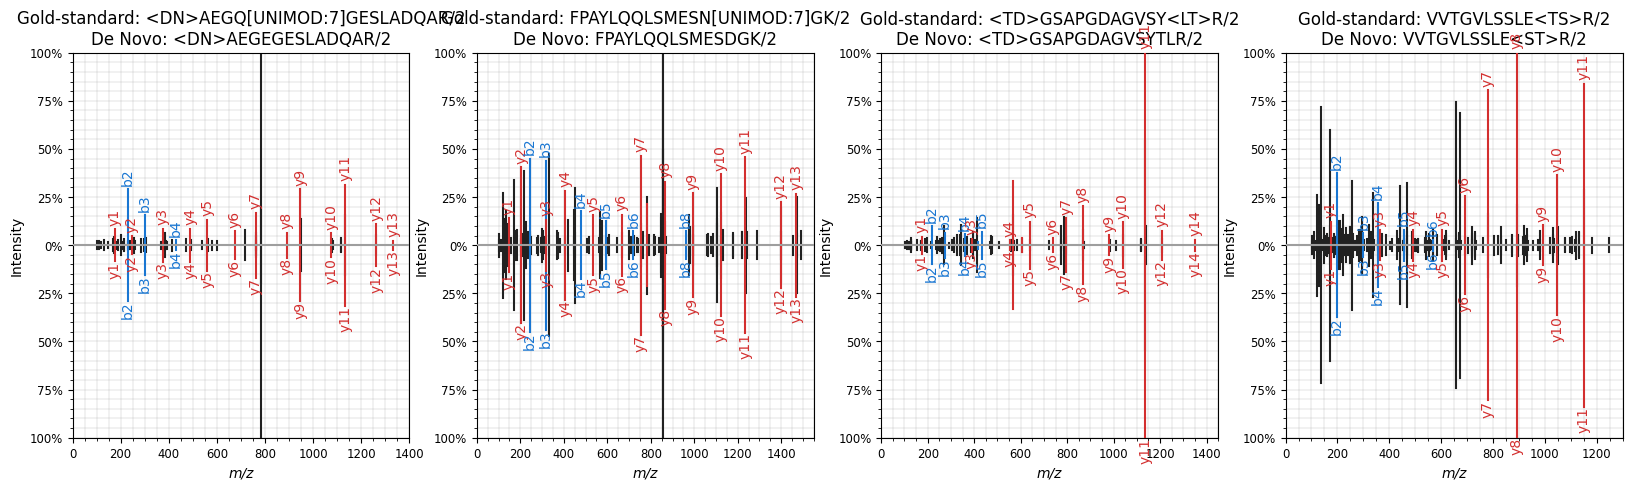

In [31]:
import spectrum_utils.plot as sup
from denovo_utils.analysis.visualization import plot_spectrum


def create_mirror(root, run_name, specid, pep_1, pep_2):

    plot_1 = plot_spectrum(
        peak_path=os.path.join(root, run_name),
        spectrum_id=specid,
        peptide=pep_1,
        peak_format='mgf',
        plot=False
    )
    plot_2 = plot_spectrum(
        peak_path=os.path.join(root, run_name),
        spectrum_id=specid,
        peptide=pep_2,
        peak_format='mgf',
        plot=False
    )
    return plot_1, plot_2


for run_name, run in runs.items():
    fig, ax = plt.subplots(1,4, figsize=(20,5))
    i = 0
    for specid in specids_all_false[specids_all_false['run']==run_name]['specid'].tolist():
        spectrum = run.get_spectrum(specid)
        
        # if spectrum.psm_candidates[0].metadata['match_type'] == 'No match - In FASTA':
        #     continue

        p1, p2 = create_mirror(
            root='/public/compomics3/Sam/PXD028735/QExactive/mgf_reformatted',
            run_name=f'{run_name}.mgf',
            specid=specid,
            pep_1=spectrum.psm_gold_standard[0].peptidoform.proforma,
            pep_2=spectrum.psm_candidates[0].peptidoform.proforma
        )
        sup.mirror(p1,p2, ax=ax[i])
        ax[i].set_title(f'Gold-standard: {spectrum.psm_gold_standard[0].peptide_evidence}\nDe Novo: {spectrum.psm_candidates[0].peptide_evidence}')
        i += 1
        if i == 4:
            break
    fig.show()
    plt.show(f"Suppl_mirrorspec_{run_name}_panel_allfalse")